# Perceptron 


In [9]:
# divide the dataset 
# 1 to T loops 
# then each loop 1 to n
# n= no of different classifications 
#x(vector)=both the points sepal width and sepal length
# sepal length at x axis 
# sepal width at y axis
#x=np.array([sepal_len,sepal_width])
#t = no of  classifications 
#x=[setosa_vals,versicolour_vals]
# n= len(setosa_dataset),len(versicolor_dataset)

In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [ ]:
data=pd.read_csv('iris_data.csv')
df=pd.DataFrame(data)
setosa=df[df['species']=='setosa']
versicolour=df[df['species']=='versicolor']

a=np.array([setosa['sepal_length']]).T
b=np.array([setosa['sepal_width']]).T
setosa_vals=np.hstack([a,b])
setosa_vals
c=np.array([versicolour['sepal_length']]).T
d=np.array([versicolour['sepal_width']]).T
versi_vals=np.hstack([c,d])

n=[len(setosa_vals),len(versi_vals)]



In [13]:
# x=[setosa_vals,versi_vals]
# theta,theta0=perceptron(10,2,50,x)
# print(theta,theta0)

# x_vals = np.linspace(4, 10, 2)
# y_vals = -(theta[0,0]* x_vals + theta0[0]) / theta[0,1]

# plt.plot(x_vals,y_vals)
# plt.scatter(a,b)
# plt.scatter(c,d)

# plt.show()

c.T[0].ndim

1

In [ ]:
import plotly.graph_objects as go

def real_time_show(L,a,b,c,d):
    x = np.linspace(-8, 8, 100)
    frames = []
    for theta,theta0 in L:
        y = -(theta[0,0]* x + theta0[0]) / theta[0,1]
        equation_text = f"y = {-(theta[0,0]/ theta[0,1])}x + {-(theta0[0] / theta[0,1])}"
        frames.append(
            go.Frame(
                data=[
                    go.Scatter(x=x, y=y, mode='lines', line=dict(width=3, color='royalblue')),
                    go.Scatter(x=[5], y=[4.5], text=[equation_text], mode='text', textfont=dict(size=18))
                ]   
            )
        )

   
    fig = go.Figure(
        data=[
            go.Scatter(x=x, y=x, mode='lines', line=dict(width=3, color='royalblue')),
            go.Scatter(x=[5], y=[4.5], text=["y = 1.00x"], mode='text', textfont=dict(size=18))
        ],
        layout=go.Layout(
            title="Line Transformation with Live Equation Update",
            xaxis=dict(range=[ 4, 7], zeroline=True),
            yaxis=dict(range=[1.5, 5], zeroline=True),
            updatemenus=[{
                'type': 'buttons',
                'buttons': [
                    {'label': 'Play', 'method': 'animate', 'args': [None, {"frame": {"duration": 50, "redraw": True}}]},
                    {'label': 'Pause', 'method': 'animate', 'args': [[None], {"mode": "immediate", "frame": {"duration": 0}}]}
                ]
            }]
        ),
        frames=frames
    )
    fig.add_trace(go.Scatter(x=a.T[0], y=b.T[0], mode='markers', 
                         marker=dict(size=10, color='red')))
    fig.add_trace(go.Scatter(x=c.T[0], y=d.T[0], mode='markers', 
                         marker=dict(size=10, color='green')))
    fig.show()


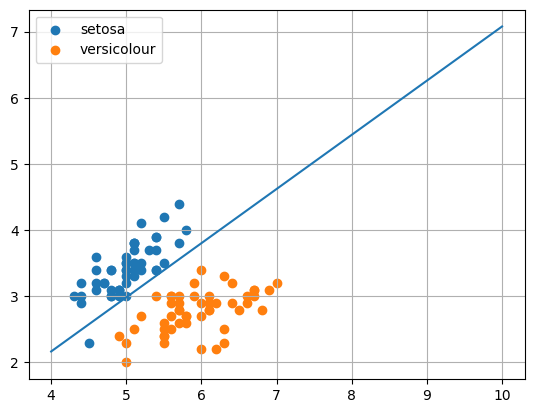

[[-73.9  90.3]] [100.]


In [ ]:
#better and original version
x=np.concatenate((setosa_vals,versi_vals))
y=np.array([1]*len(setosa_vals)+[-1]*len(versi_vals))

def original_perceptron(T,y,x,setosa_vals,versi_vals):
    L=[]
    error_list=[]
    theta = np.zeros((1,2))
    theta0 = np.zeros(1)
    for _ in range(T):
        for i,xi in enumerate(x):
            if y[i] * (np.dot(theta,xi) + theta0) <= 0:
                theta = theta + y[i]*xi
                theta0 = theta0 + y[i]
        error=error_calc(theta,theta0,x,setosa_vals,versi_vals) 
        error_list.append(error) 
        L.append(tuple((theta,theta0)))
    return theta,theta0,error_list,L

def error_calc(theta,theta0,x,versi_vals,setosa_vals):
    error= 0   
    for a,b in zip(setosa_vals,versi_vals):
        if (np.dot(theta,b) + theta0)*(np.dot(theta,a) + theta0)<0:
            error=error
        else:
            error=error+1    
    return error/50

theta , theta0 ,l,L = original_perceptron(500,y,x,setosa_vals,versi_vals) 
x_vals = np.linspace(4, 10, 2)
y_vals = -(theta[0,0]* x_vals + theta0[0]) / theta[0,1]
real_time_show(L,a,b,c,d)      
plt.plot(x_vals,y_vals)
plt.scatter(a,b,label='setosa')
plt.scatter(c,d,label='versicolour')

plt.grid(True)
plt.legend()
plt.show()  
print(theta,theta0)

In [24]:
def probab(vals):
    y=np.array([])
    for xi in vals:
        
        y=np.append(y,1/(1+np.exp(-(np.dot(theta, xi) + theta0)
                                 )
                        )
                    )
    return np.mean(y)    

print(probab(versi_vals))


1.1787361229503981e-14
